<a href="https://colab.research.google.com/github/JordanDCunha/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# 📦 Install required packages
# =========================
!pip install -q numpy scipy matplotlib pandas scikit-learn mglearn ipython

# =========================
# 📚 Core imports
# =========================
import sys
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import mglearn
import sklearn
import IPython

# =========================
# 📊 scikit-learn utilities
# =========================
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# =========================
# 🧪 Display + plotting setup
# =========================
from IPython.display import display
%matplotlib inline

# =========================
# ✅ Sanity check
# =========================
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("SciPy:", sp.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("mglearn: loaded successfully")


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
NumPy: 2.0.2
SciPy: 1.16.3
pandas: 2.2.2
matplotlib: 3.10.0
scikit-learn: 1.6.1
mglearn: loaded successfully


### Chapter 3: Unsupervised Learning and Preprocessing

- The second major family of machine learning algorithms is **unsupervised learning**.
- In unsupervised learning:
  - There is **no known output**
  - There is **no teacher or labeled data** to guide the algorithm
- The algorithm is given **only input data**.
- The goal is to:
  - Discover structure
  - Extract patterns
  - Gain insight directly from the data itself
- Unlike supervised learning, unsupervised learning does **not** involve prediction of predefined labels.


### 3.1 Types of Unsupervised Learning

- In this chapter, we focus on **two main kinds of unsupervised learning**:
  - **Unsupervised transformations**
  - **Clustering**

#### Unsupervised Transformations
- Create a **new representation of the data** that is easier for:
  - Humans to interpret
  - Machine learning algorithms to process
- Do not use labeled outputs
- Common goals include:
  - Simplifying data
  - Highlighting important structure

##### Dimensionality Reduction
- A key example of unsupervised transformation
- Takes **high-dimensional data** (many features)
- Produces a **lower-dimensional representation**
- Preserves the **essential characteristics** of the data
- Commonly used to:
  - Reduce data to **two dimensions**
  - Enable **visualization**

##### Component or Topic Discovery
- Another application of unsupervised transformations
- Identifies **parts or components** that make up the data
- Example: **Topic extraction** from text documents
  - Learns:
    - Which topics exist
    - Which topics appear in each document
- Useful for tracking themes such as:
  - Elections
  - Gun control
  - Pop stars
  - Social media trends

#### Clustering
- Groups data into **distinct sets of similar items**
- Does not require knowing:
  - The correct labels
  - The number of groups in advance
- Example use case:
  - Grouping photos on a social media platform
  - Faces are extracted and grouped by visual similarity
  - Ideally, each group corresponds to a **single person**


### 3.2 Challenges in Unsupervised Learning

- A major challenge in unsupervised learning is **evaluation**.
- Most unsupervised algorithms are applied to data **without labels**.
- Because there is no known correct output:
  - We don’t know what the “right answer” should be
  - It is difficult to determine whether a model performed well

#### Difficulty of Evaluation
- An unsupervised algorithm might find **patterns that are valid**, but not useful
- Example:
  - A clustering algorithm groups face images by:
    - Profile vs. full-face pictures
  - This is a valid grouping
  - But it may not match the intended goal (e.g., grouping by person)
- There is usually **no way to tell the algorithm** what kind of structure we want
- As a result:
  - Evaluation often relies on **manual inspection**

#### Exploratory Nature of Unsupervised Learning
- Unsupervised learning is commonly used for:
  - **Exploratory data analysis**
  - Gaining insight into the structure of the data
- It is less often used as a fully automatic, end-to-end system

#### Unsupervised Learning as Preprocessing
- Another common use is as a **preprocessing step** for supervised learning
- Learning a new data representation can:
  - Improve accuracy of supervised models
  - Reduce memory usage
  - Reduce computational time

#### Preprocessing and Scaling
- Before introducing “real” unsupervised algorithms:
  - We first discuss **simple preprocessing methods**
- Even though preprocessing is often used with supervised learning:
  - Scaling and preprocessing methods **do not use labels**
  - Therefore, they are considered **unsupervised methods**


### 3.3 Preprocessing and Scaling

- Some machine learning algorithms are **very sensitive to feature scaling**
  - Examples: **Support Vector Machines (SVMs)** and **Neural Networks**
- Preprocessing adjusts features to make data more suitable for learning
- Most preprocessing involves:
  - Per-feature **rescaling**
  - Per-feature **shifting**
- These methods are **unsupervised**
  - They do not use labels


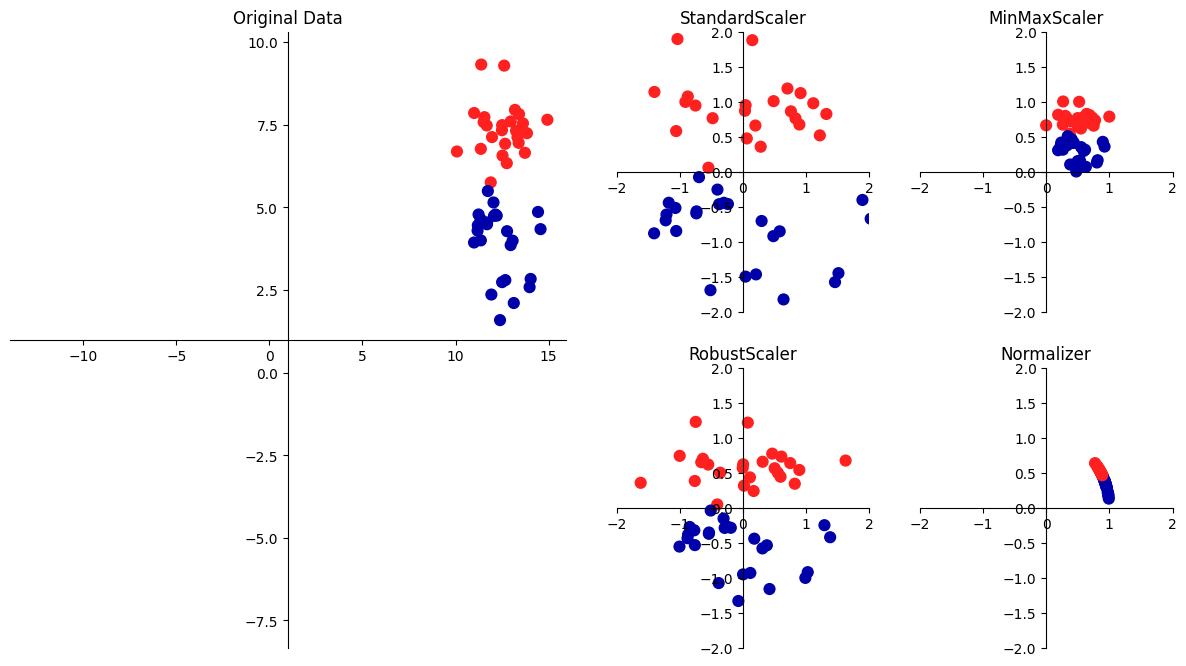

In [2]:
mglearn.plots.plot_scaling()


### 3.3.1 Different Kinds of Preprocessing

- Original dataset:
  - Two features with very different value ranges
- Goal of preprocessing:
  - Bring features to **comparable scales**

#### Common Scaling Methods in scikit-learn

- **StandardScaler**
  - Mean = 0
  - Variance = 1
  - Does not enforce min/max bounds

- **RobustScaler**
  - Uses median and quartiles instead of mean and variance
  - Less sensitive to outliers

- **MinMaxScaler**
  - Scales features to a fixed range (usually 0 to 1)
  - All data lies inside a unit square (for 2D data)

- **Normalizer**
  - Scales each *data point* to have unit Euclidean length
  - Preserves direction, not magnitude
  - Useful when angle/direction matters more than size


### 3.3.2 Applying Data Transformations

- Preprocessing is usually applied **before supervised learning**
- We use the **breast cancer dataset**
- Dataset properties:
  - 569 samples
  - 30 features per sample
- Dataset is split into:
  - Training set
  - Test set


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=1)

print(X_train.shape)
print(X_test.shape)


(426, 30)
(143, 30)


- Preprocessing objects follow the same pattern as models:
  - Import the class
  - Instantiate it
  - Call `fit` on training data only
- Scalers do **not** use target labels (`y`)


In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)


MinMaxScaler()

- `transform` applies the learned scaling
- Shape of the data does not change
- Values are shifted and rescaled only


In [5]:
X_train_scaled = scaler.transform(X_train)

print("transformed shape:", X_train_scaled.shape)
print("per-feature minimum before scaling:\n", X_train.min(axis=0))
print("per-feature maximum before scaling:\n", X_train.max(axis=0))
print("per-feature minimum after scaling:\n", X_train_scaled.min(axis=0))
print("per-feature maximum after scaling:\n", X_train_scaled.max(axis=0))


transformed shape: (426, 30)
per-feature minimum before scaling:
 [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.263e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 5.024e-02 1.153e-01 3.602e-01 7.570e-01 6.802e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 9.539e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.566e-01 5.521e-02]
per-feature maximum before scaling:
 [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 2.867e-01 4.268e-01
 2.012e-01 3.040e-01 9.575e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 6.146e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 9.379e-01 1.170e+00 2.910e-01
 5.774e-01 1.486e-01]
per-feature minimum after scaling:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
per-feature maximum after scaling:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


- The **same transformation** must be applied to the test set
- Test data may end up:
  - Outside the 0–1 range
- This is expected and correct
- Scaling always uses **training-set statistics**


In [6]:
X_test_scaled = scaler.transform(X_test)

print("per-feature minimum after scaling:\n", X_test_scaled.min(axis=0))
print("per-feature maximum after scaling:\n", X_test_scaled.max(axis=0))


per-feature minimum after scaling:
 [ 0.0336031   0.0226581   0.03144219  0.01141039  0.14128374  0.04406704
  0.          0.          0.1540404  -0.00615249 -0.00137796  0.00594501
  0.00430665  0.00079567  0.03919502  0.0112206   0.          0.
 -0.03191387  0.00664013  0.02660975  0.05810235  0.02031974  0.00943767
  0.1094235   0.02637792  0.          0.         -0.00023764 -0.00182032]
per-feature maximum after scaling:
 [0.9578778  0.81501522 0.95577362 0.89353128 0.81132075 1.21958701
 0.87956888 0.9333996  0.93232323 1.0371347  0.42669616 0.49765736
 0.44117231 0.28371044 0.48703131 0.73863671 0.76717172 0.62928585
 1.33685792 0.39057253 0.89612238 0.79317697 0.84859804 0.74488793
 0.9154725  1.13188961 1.07008547 0.92371134 1.20532319 1.63068851]


### 3.3.3 Scaling Training and Test Data the Same Way

- Training and test data **must be scaled identically**
- Scaling them separately:
  - Changes the geometry of the data
  - Breaks the relationship between train and test sets
- This leads to incorrect model evaluation


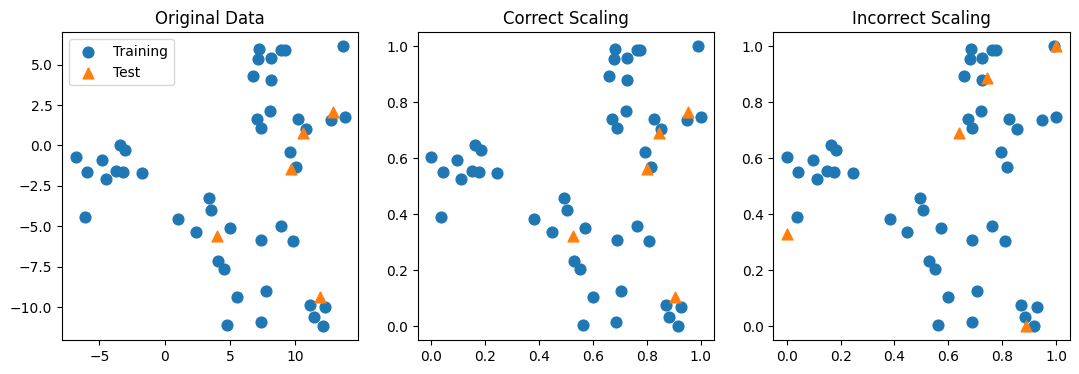

In [7]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# create synthetic blob data
X_blobs, _ = make_blobs(
    n_samples=50, centers=5, random_state=4, cluster_std=2
)

# train-test split (NOTE: different variable names)
X_blobs_train, X_blobs_test = train_test_split(
    X_blobs, random_state=5, test_size=0.1
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# --- Original data ---
axes[0].scatter(X_blobs_train[:, 0], X_blobs_train[:, 1],
                s=60, label="Training")
axes[0].scatter(X_blobs_test[:, 0], X_blobs_test[:, 1],
                marker='^', s=60, label="Test")
axes[0].set_title("Original Data")
axes[0].legend()

# --- Correct scaling ---
scaler = MinMaxScaler()
scaler.fit(X_blobs_train)

X_blobs_train_scaled = scaler.transform(X_blobs_train)
X_blobs_test_scaled = scaler.transform(X_blobs_test)

axes[1].scatter(X_blobs_train_scaled[:, 0],
                X_blobs_train_scaled[:, 1], s=60)
axes[1].scatter(X_blobs_test_scaled[:, 0],
                X_blobs_test_scaled[:, 1],
                marker='^', s=60)
axes[1].set_title("Correct Scaling")

# --- Incorrect scaling (fit on test!) ---
test_scaler = MinMaxScaler()
test_scaler.fit(X_blobs_test)

X_blobs_test_scaled_bad = test_scaler.transform(X_blobs_test)

axes[2].scatter(X_blobs_train_scaled[:, 0],
                X_blobs_train_scaled[:, 1], s=60)
axes[2].scatter(X_blobs_test_scaled_bad[:, 0],
                X_blobs_test_scaled_bad[:, 1],
                marker='^', s=60)
axes[2].set_title("Incorrect Scaling")

plt.show()
plt.close()


### Shortcuts and Efficient Alternatives

- Many transformers support `fit_transform`
- Equivalent to calling:
  - `fit()` then `transform()`
- Often more efficient
- Best practice for training data


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)


### 3.3.4 Effect of Preprocessing on Supervised Learning

- Scaling can dramatically improve model performance
- Example: Support Vector Machine (SVC)


In [9]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (426, 30)
y_train shape: (426,)
X_test shape: (143, 30)
y_test shape: (143,)


In [10]:
from sklearn.svm import SVC

svm = SVC(C=100)
svm.fit(X_train, y_train)

print("Test set accuracy:", svm.score(X_test, y_test))


Test set accuracy: 0.9370629370629371


In [11]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
print("Scaled test set accuracy:", svm.score(X_test_scaled, y_test))


Scaled test set accuracy: 0.972027972027972


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
print("SVM test accuracy:", svm.score(X_test_scaled, y_test))


SVM test accuracy: 0.965034965034965


### 3.4 Dimensionality Reduction, Feature Extraction, and Manifold Learning

- Unsupervised transformations are used for:
  - Visualization
  - Data compression
  - Learning more informative representations
- Common algorithms:
  - **PCA (Principal Component Analysis)** – general-purpose
  - **NMF (Non-Negative Matrix Factorization)** – feature extraction
  - **t-SNE** – visualization


### 3.4.1 Principal Component Analysis (PCA)

- PCA rotates the data so that:
  - New features are **uncorrelated**
  - Directions capture **maximum variance**
- Steps:
  1. Subtract the mean
  2. Find direction of maximum variance (Component 1)
  3. Find orthogonal directions with decreasing variance
- Principal components:
  - Are directions in feature space
  - Equal in number to original features


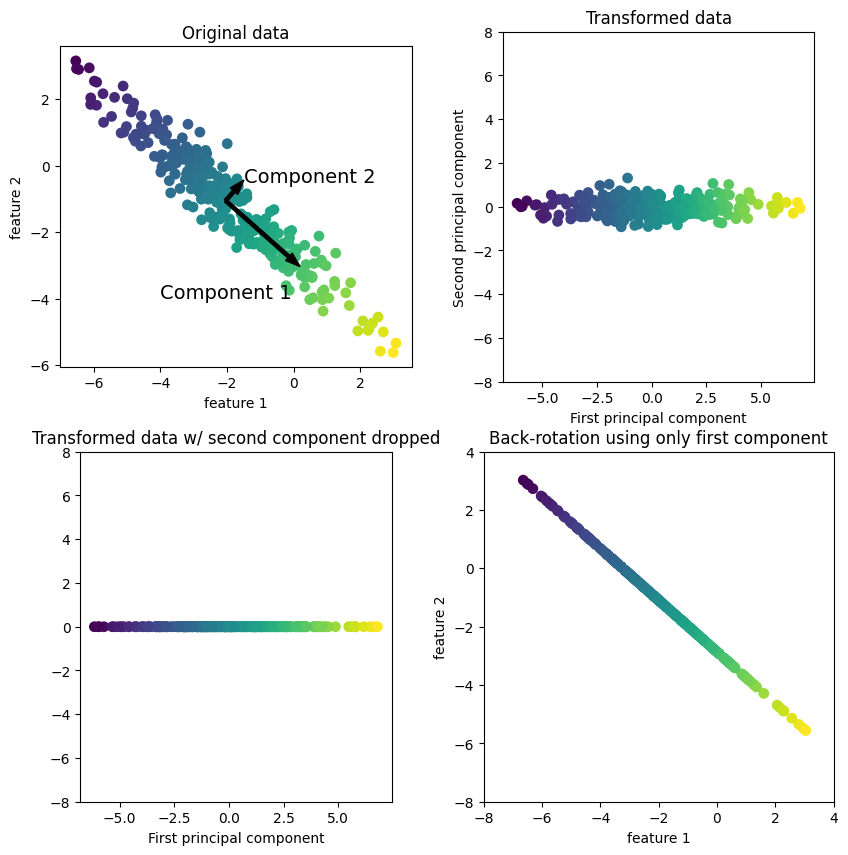

In [13]:
mglearn.plots.plot_pca_illustration()


- PCA can reduce dimensionality by:
  - Keeping only the most important components
- Example:
  - 2D → 1D by keeping first principal component
- Benefits:
  - Noise reduction
  - Visualization
  - Compression


### Applying PCA to the Breast Cancer Dataset

- Dataset has 30 features
- Pair plots would require 435 scatter plots
- Histograms show individual feature distributions
- PCA captures **feature interactions**


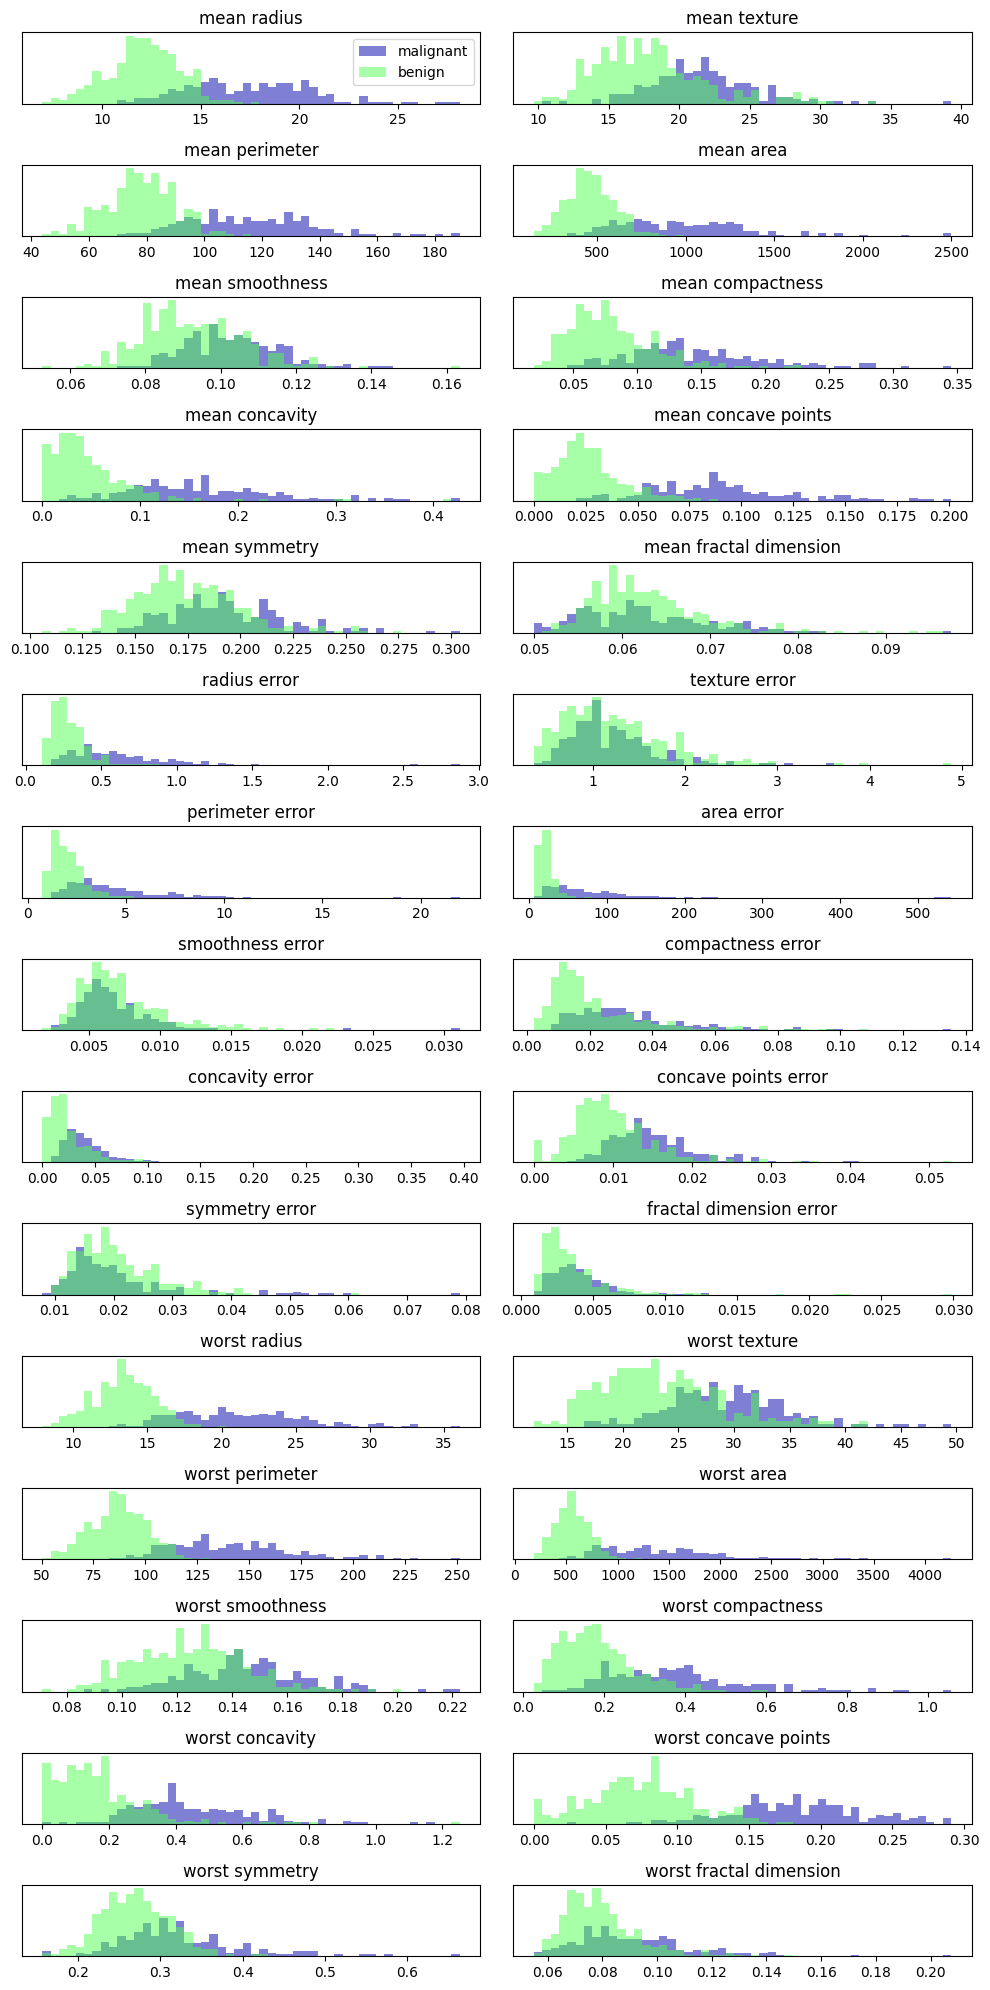

In [14]:
fig, axes = plt.subplots(15, 2, figsize=(10, 20))
malignant = cancer.data[cancer.target == 0]
benign = cancer.data[cancer.target == 1]

ax = axes.ravel()
for i in range(30):
    _, bins = np.histogram(cancer.data[:, i], bins=50)
    ax[i].hist(malignant[:, i], bins=bins, color=mglearn.cm3(0), alpha=.5)
    ax[i].hist(benign[:, i], bins=bins, color=mglearn.cm3(2), alpha=.5)
    ax[i].set_title(cancer.feature_names[i])
    ax[i].set_yticks(())
ax[0].legend(["malignant", "benign"], loc="best")
fig.tight_layout()


- PCA is affected by feature scale
- Standard practice:
  - Apply **StandardScaler** before PCA


In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cancer.data)


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca.shape)


Original shape: (569, 30)
Reduced shape: (569, 2)


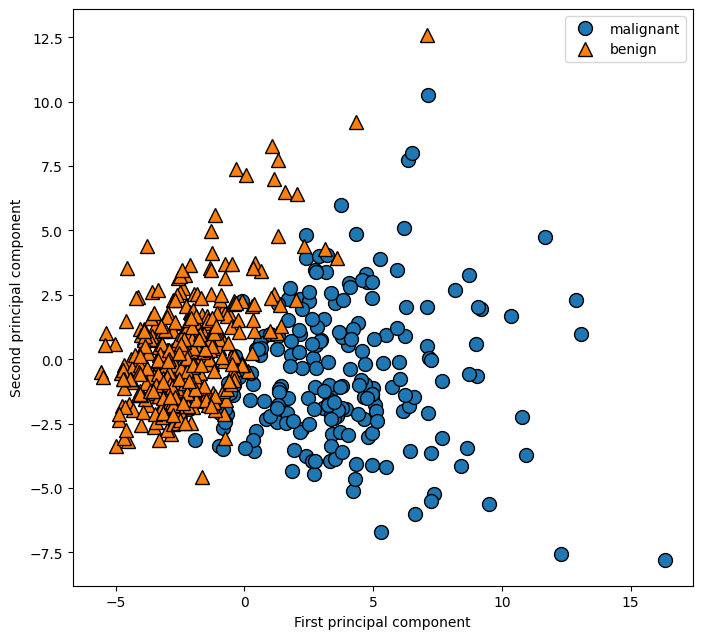

In [17]:
plt.figure(figsize=(8, 8))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], cancer.target)
plt.legend(cancer.target_names)
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.gca().set_aspect("equal")


- PCA is **unsupervised**
- Class labels are not used during fitting
- Components are:
  - Linear combinations of original features
  - Often difficult to interpret directly


In [18]:
print("PCA component shape:", pca.components_.shape)


PCA component shape: (2, 30)


Text(0, 0.5, 'Principal components')

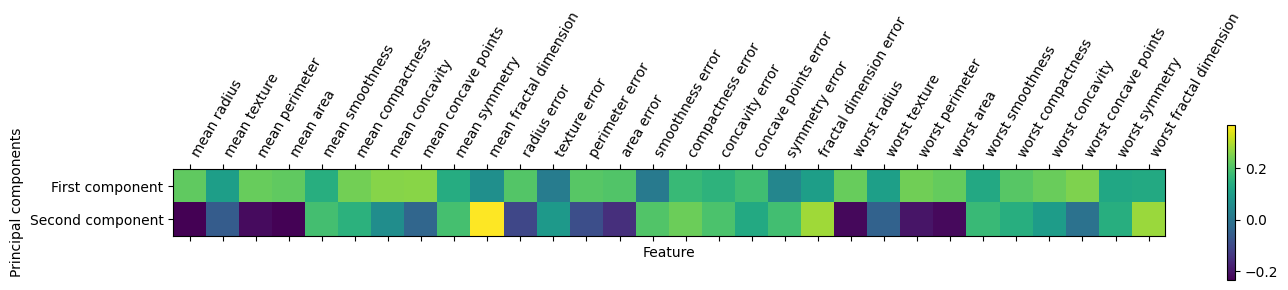

In [19]:
plt.matshow(pca.components_, cmap='viridis')
plt.yticks([0, 1], ["First component", "Second component"])
plt.colorbar()
plt.xticks(range(len(cancer.feature_names)),
           cancer.feature_names, rotation=60, ha='left')
plt.xlabel("Feature")
plt.ylabel("Principal components")


### PCA for Feature Extraction (Eigenfaces)

- Images consist of many pixels
- PCA finds meaningful directions in pixel space
- Applications:
  - Face recognition
  - Image compression


In [20]:
from sklearn.datasets import fetch_lfw_people

people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)
image_shape = people.images[0].shape


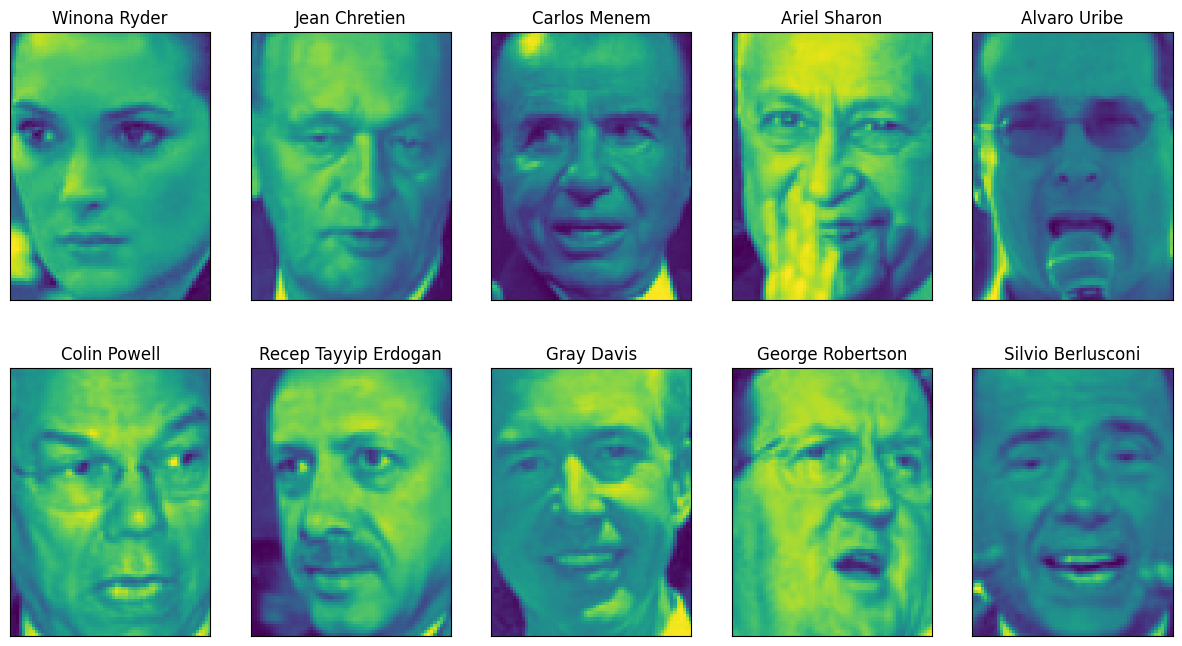

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(15, 8),
                         subplot_kw={'xticks': (), 'yticks': ()})
for target, image, ax in zip(people.target, people.images, axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])


- Raw pixel distances are poor similarity measures
- PCA:
  - Captures structure
  - Improves distance-based classification
- Whitening:
  - Scales components to equal variance


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

X_people = people.data / 255.
y_people = people.target

X_train, X_test, y_train, y_test = train_test_split(
    X_people, y_people, stratify=y_people, random_state=0)

pca = PCA(n_components=100, whiten=True, random_state=0)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)
print("Test accuracy:", knn.score(X_test_pca, y_test))


Test accuracy: 0.4470899470899471


- `inverse_transform` reconstructs original space
- Fewer components:
  - Preserve global structure
  - Lose fine details


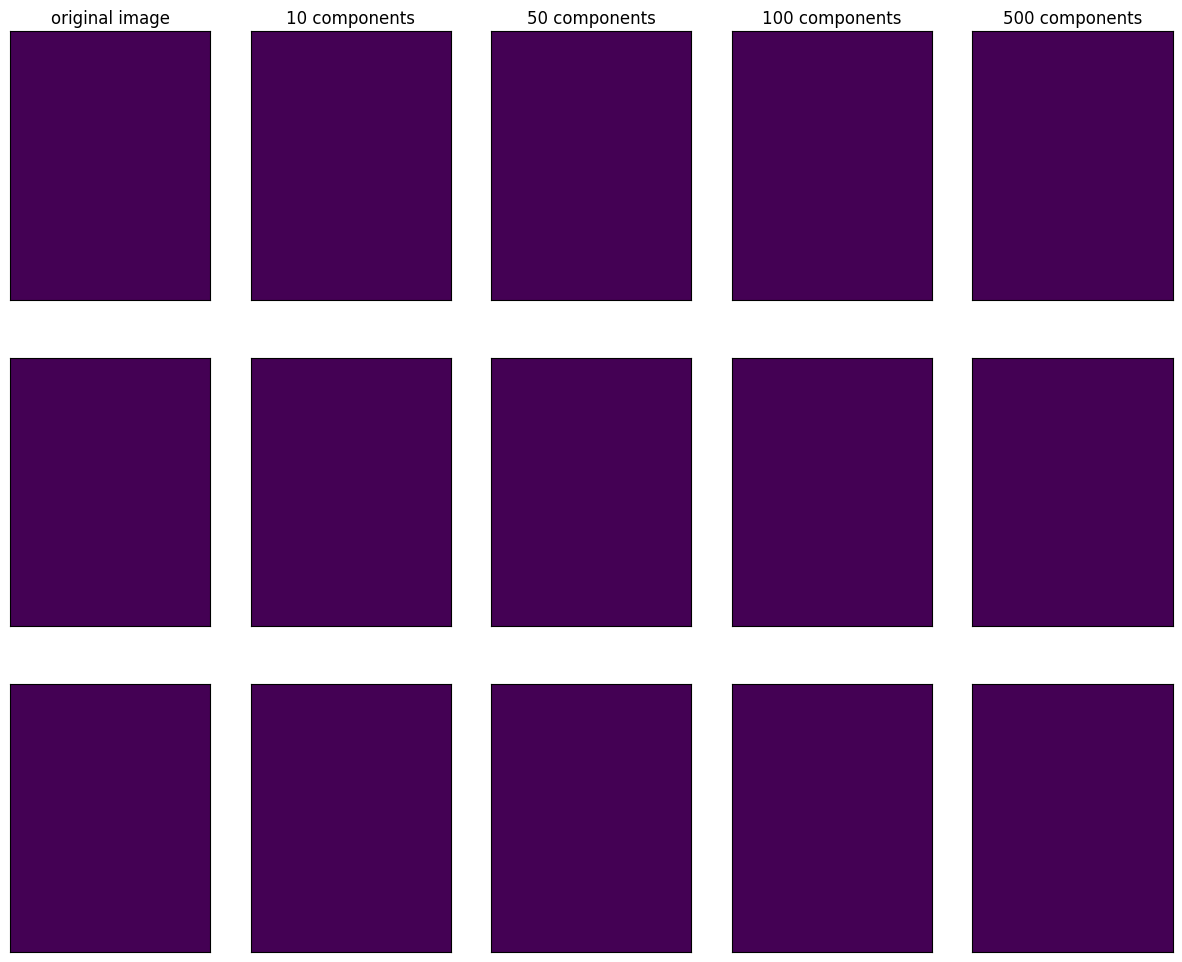

In [23]:
mglearn.plots.plot_pca_faces(X_train, X_test, image_shape)


### 3.4.2 Non-Negative Matrix Factorization (NMF)

- Like PCA, decomposes data into components
- Key differences:
  - Components and coefficients are **non-negative**
  - Data must be non-negative
- Produces more interpretable components
- Useful for:
  - Images
  - Audio
  - Text


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


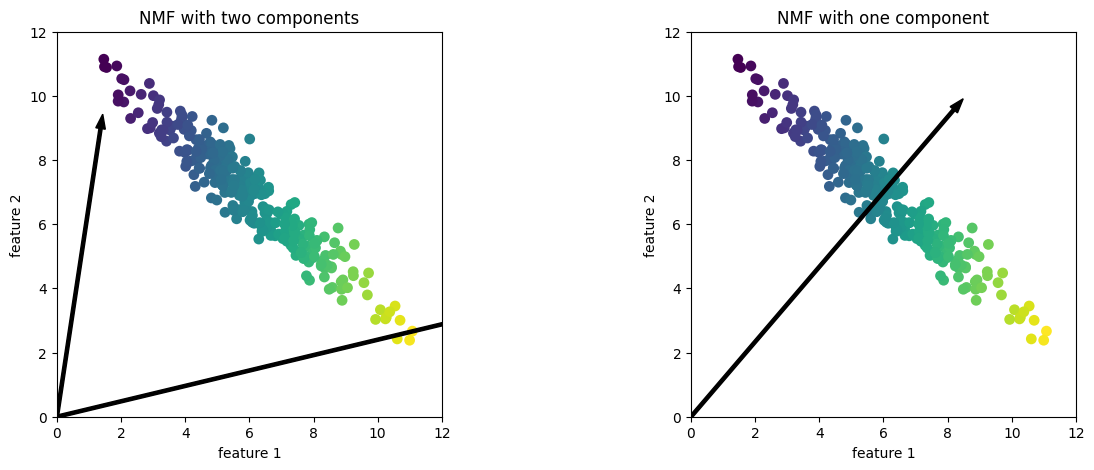

In [24]:
mglearn.plots.plot_nmf_illustration()


In [25]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=15, random_state=0)
X_train_nmf = nmf.fit_transform(X_train)
X_test_nmf = nmf.transform(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


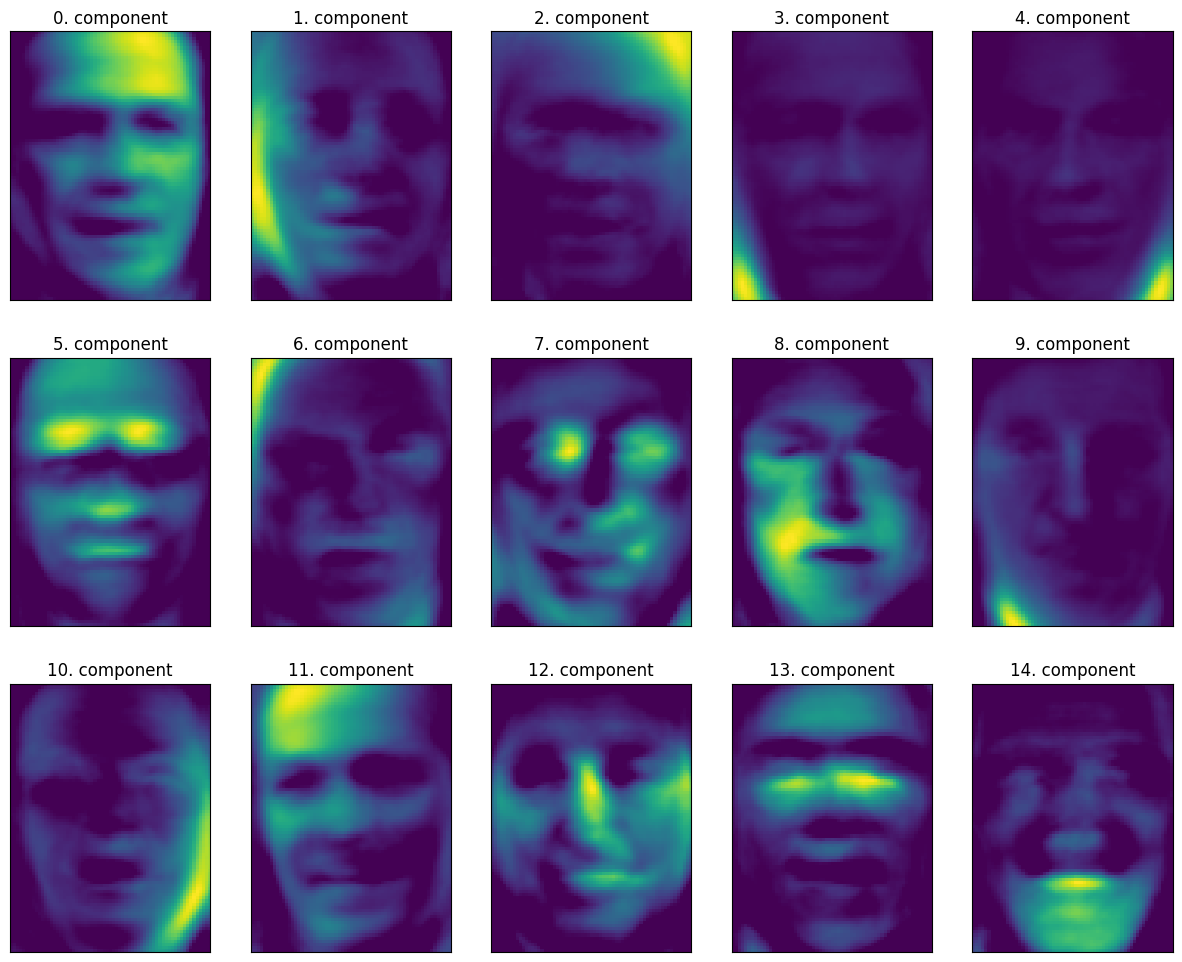

In [26]:
fig, axes = plt.subplots(3, 5, figsize=(15, 12),
                         subplot_kw={'xticks': (), 'yticks': ()})
for i, (component, ax) in enumerate(zip(nmf.components_, axes.ravel())):
    ax.imshow(component.reshape(image_shape))
    ax.set_title(f"{i}. component")


### 3.4.3 Manifold Learning with t-SNE

- Manifold learning focuses on visualization
- t-SNE:
  - Preserves local neighborhood structure
  - Emphasizes nearby points
  - Produces 2D embeddings
- Limitations:
  - No transform method
  - Not used for predictive pipelines


In [27]:
from sklearn.datasets import load_digits

digits = load_digits()
pca = PCA(n_components=2)
digits_pca = pca.fit_transform(digits.data)


In [28]:
from sklearn.manifold import TSNE

tsne = TSNE(random_state=42)
digits_tsne = tsne.fit_transform(digits.data)


In [ ]:
plt.figure(figsize=(10, 10))
for i in range(len(digits.data)):
    plt.text(digits_tsne[i, 0], digits_tsne[i, 1],
             str(digits.target[i]),
             fontdict={'weight': 'bold', 'size': 9})
plt.xlabel("t-SNE feature 0")
plt.ylabel("t-SNE feature 1")


Text(0, 0.5, 't-SNE feature 1')

## 3.5 Clustering

Clustering is the task of partitioning a dataset into groups, called *clusters*.  
The goal is to split the data so that points within the same cluster are very similar, while points in different clusters are dissimilar.

Like classification, clustering assigns a label (a number) to each data point.  
However, unlike classification, these labels have **no ground-truth meaning**—they are arbitrary identifiers.


### 3.5.1 k-Means Clustering

k-means is one of the simplest and most widely used clustering algorithms.  
It finds cluster centers that represent regions of the data.

The algorithm alternates between two steps:
1. Assign each data point to the nearest cluster center
2. Update each cluster center to be the mean of its assigned points

The algorithm stops when assignments no longer change.


In [ ]:
import mglearn
mglearn.plots.plot_kmeans_algorithm()


After convergence, each cluster is represented by its center.  
New data points are assigned to the nearest center.


In [ ]:
mglearn.plots.plot_kmeans_boundaries()


### Applying k-Means with scikit-learn


In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic data
X, y = make_blobs(random_state=1)

# Build the model
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)


Each data point is assigned a cluster label, stored in `labels_`.


In [ ]:
print("Cluster memberships:\n{}".format(kmeans.labels_))


You can also assign cluster labels to new data using `predict`.  
Predicting on the training data returns the same result.


In [ ]:
print(kmeans.predict(X))


Cluster labels themselves have no intrinsic meaning.  
Only which points belong together matters, not the numeric label.


In [ ]:
import matplotlib.pyplot as plt

mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    [0, 1, 2],
    markers='^',
    markeredgewidth=2
)


### Choosing the Number of Clusters

k-means requires specifying the number of clusters in advance.  
Using too few or too many clusters can significantly change results.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Two clusters
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, ax=axes[0])

# Five clusters
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)
mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, ax=axes[1])


### Failure Cases of k-Means

k-means assumes:
- Clusters are convex
- All clusters have similar size
- All directions are equally important

These assumptions can lead to poor results.


In [ ]:
X_varied, y_varied = make_blobs(
    n_samples=200,
    cluster_std=[1.0, 2.5, 0.5],
    random_state=170
)

y_pred = KMeans(n_clusters=3, random_state=0).fit_predict(X_varied)

mglearn.discrete_scatter(X_varied[:, 0], X_varied[:, 1], y_pred)
plt.legend(["cluster 0", "cluster 1", "cluster 2"])


k-means also struggles with elongated or non-spherical clusters.


In [ ]:
import numpy as np

X, y = make_blobs(random_state=170, n_samples=600)
rng = np.random.RandomState(74)

transformation = rng.normal(size=(2, 2))
X = np.dot(X, transformation)

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_)
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    [0, 1, 2],
    markers='^'
)


k-means completely fails on complex shapes like the two-moons dataset.


In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
y_pred = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=60, edgecolor='k')
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='^',
    s=100
)


### Vector Quantization Perspective

k-means can be viewed as a decomposition method:
each data point is represented by exactly one cluster center.

This is known as *vector quantization*.


Using many clusters can create a higher-dimensional representation of the data,
making complex shapes linearly separable.


In [ ]:
kmeans = KMeans(n_clusters=10, random_state=0)
kmeans.fit(X)

distance_features = kmeans.transform(X)
print("Distance feature shape:", distance_features.shape)


k-means is fast and scalable, but:
- Requires choosing the number of clusters
- Is sensitive to initialization
- Assumes simple cluster geometry


### 3.5.2 Agglomerative Clustering

Agglomerative clustering starts with each point as its own cluster
and repeatedly merges the closest clusters until a stopping criterion is met.


from sklearn.cluster import AgglomerativeClustering

X, y = make_blobs(random_state=1)

agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(X)

mglearn.discrete_scatter(X[:, 0], X[:, 1], assignment)


from sklearn.cluster import AgglomerativeClustering

X, y = make_blobs(random_state=1)

agg = AgglomerativeClustering(n_clusters=3)
assignment = agg.fit_predict(X)

mglearn.discrete_scatter(X[:, 0], X[:, 1], assignment)


In [ ]:
from scipy.cluster.hierarchy import dendrogram, ward

X, y = make_blobs(random_state=0, n_samples=12)
linkage_array = ward(X)

dendrogram(linkage_array)
plt.xlabel("Sample index")
plt.ylabel("Cluster distance")


### 3.5.3 DBSCAN

DBSCAN is a density-based clustering algorithm.

Advantages:
- No need to specify number of clusters
- Can find complex shapes
- Identifies noise and outliers


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN()
clusters = dbscan.fit_predict(X)

print("Cluster memberships:", clusters)


DBSCAN depends heavily on two parameters:
- `eps`: neighborhood size
- `min_samples`: minimum cluster size


In [ ]:
mglearn.plots.plot_dbscan()


DBSCAN successfully separates complex shapes like the two-moons dataset.


In [ ]:
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN()
clusters = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, s=60)


### 3.5.4 Comparing and Evaluating Clustering Algorithms

Clustering evaluation is difficult because ground truth is often unavailable.


In [ ]:
from sklearn.metrics.cluster import adjusted_rand_score

print("ARI:", adjusted_rand_score([0,0,1,1], [1,1,0,0]))


Accuracy should not be used for clustering evaluation.
Cluster labels are arbitrary.


### Key Takeaways

- k-means is fast but limited
- Agglomerative clustering builds hierarchies
- DBSCAN handles noise and complex shapes
- Clustering often requires manual inspection


## 3.6 Summary and Outlook

This chapter introduced a range of unsupervised learning algorithms that can be applied for exploratory data analysis and preprocessing. Having the right representation of the data is often crucial for supervised or unsupervised learning to succeed, and preprocessing and decomposition methods play an important part in data preparation.

Decomposition, manifold learning, and clustering are essential tools to further your understanding of your data, and can be the only ways to make sense of your data in the absence of supervision information. Even in a supervised setting, exploratory tools are important for a better understanding of the properties of the data.

Often it is hard to quantify the usefulness of an unsupervised algorithm, though this shouldn’t deter you from using them to gather insights from your data. With these methods under your belt, you are now equipped with all the essential learning algorithms that machine learning practitioners use every day.

We encourage you to try clustering and decomposition methods both on two-dimensional toy data and on real-world datasets included in scikit-learn, like the digits, iris, and cancer datasets.


## Summary of the Estimator Interface

Let’s briefly review the API that we introduced in Chapters 2 and 3.

All algorithms in scikit-learn, whether preprocessing, supervised learning, or unsupervised learning algorithms, are implemented as classes. These classes are called **estimators** in scikit-learn.

To apply an algorithm, you first have to instantiate an object of the particular class.


In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()


The estimator class contains the algorithm, and also stores the model that is learned from data using the algorithm.

You should set any parameters of the model when constructing the model object. These parameters include regularization, complexity control, number of clusters to find, etc.

All estimators have a `fit` method, which is used to build the model. The `fit` method always requires as its first argument the data `X`, represented as a NumPy array or a SciPy sparse matrix, where each row represents a single data point.

The data `X` is always assumed to have continuous (floating-point) entries.

Supervised algorithms also require a `y` argument, which is a one-dimensional NumPy array containing target values for regression or classification.


There are two main ways to apply a learned model in scikit-learn:

- To create a prediction in the form of a new output like `y`, use the `predict` method.
- To create a new representation of the input data `X`, use the `transform` method.


### Common Estimator Methods



In [ ]:
estimator.fit(X_train, y_train)
estimator.predict(X_test)
estimator.transform(X_test)

### Typical Use Cases

- **Classification** → `predict`
- **Regression** → `predict`
- **Clustering** → `predict`
- **Preprocessing** → `transform`
- **Dimensionality reduction** → `transform`
- **Feature extraction** → `transform`
- **Feature selection** → `transform`


Additionally, all supervised models have a `score(X_test, y_test)` method that allows an evaluation of the model.

Here, `X_train` and `y_train` refer to the training data and training labels, while `X_test` refers to the test data and test labels (if applicable).


### Footnotes

1. The median of a set of numbers is the number *x* such that half of the numbers are smaller than *x* and half of the numbers are larger than *x*.  
   The lower quartile is the number *x* such that one-fourth of the numbers are smaller than *x*, and the upper quartile is the number *x* such that one-fourth of the numbers are larger than *x*.

2. Not to be confused with the much larger MNIST dataset.

3. If you don’t provide `n_clusters`, it is set to 8 by default. There is no particular reason why you should use this value.

4. In this case, “best” means that the sum of variances of the clusters is small.

5. We could also use the `labels_` attribute, as we did for k-means.
